In [3]:
import cv2
import numpy as np
import pyrealsense2 as rs
from ultralytics import YOLO

검출 개수: 0


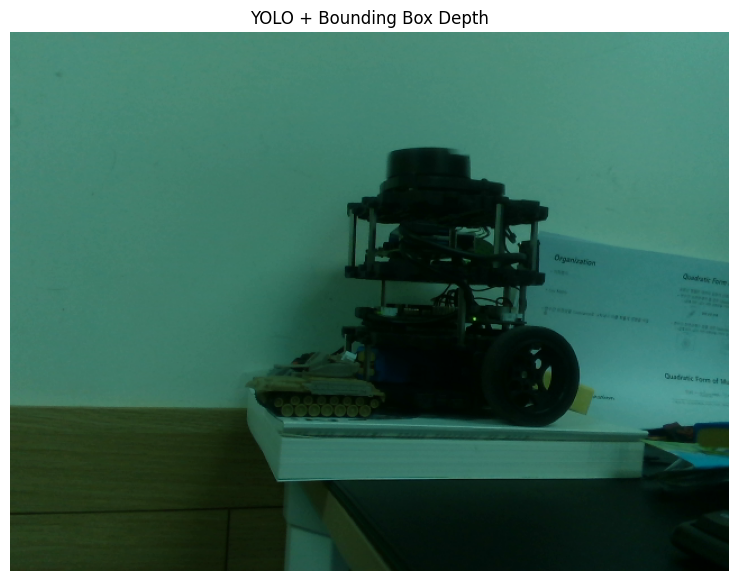

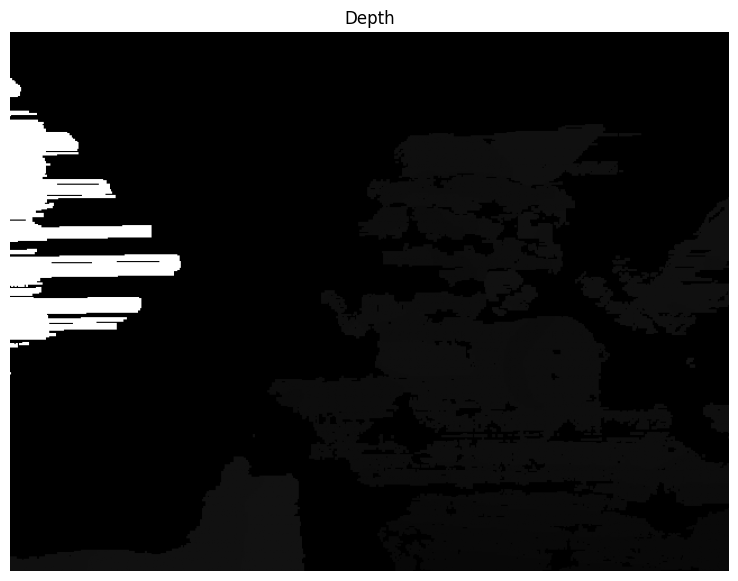

In [57]:
import pyrealsense2 as rs
import numpy as np
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO


IMGSZ = 416
CONF = 0.4

COLOR_W, COLOR_H = 640, 480
DEPTH_W, DEPTH_H = 640, 480


model = YOLO("../train/runs/detect/train_baseline_reduced/yolo26n_train_baseline_reduced/weights/best.pt", task="detect")
pipeline = rs.pipeline()
config = rs.config()

config.enable_stream(rs.stream.color, COLOR_W, COLOR_H, rs.format.bgr8, 30)
config.enable_stream(rs.stream.depth, DEPTH_W, DEPTH_H, rs.format.z16, 30)

pipeline.start(config)
align = rs.align(rs.stream.color)

def get_box_depth_stats(depth_frame, depth_raw, x1, y1, x2, y2):
    h, w = depth_raw.shape

    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(0, min(int(x2), w - 1))
    y2 = max(0, min(int(y2), h - 1))

    if x2 <= x1 or y2 <= y1:
        return {
            "center_m": 0.0,
            "median_m": 0.0,
            "mean_m": 0.0,
            "min_m": 0.0,
            "max_m": 0.0,
            "valid_pixels": 0
        }

    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2

    center_m = depth_frame.get_distance(cx, cy)

    roi = depth_raw[y1:y2, x1:x2]
    valid = roi[roi > 0]

    if len(valid) == 0:
        return {
            "center_m": center_m,
            "median_m": 0.0,
            "mean_m": 0.0,
            "min_m": 0.0,
            "max_m": 0.0,
            "valid_pixels": 0
        }

    scale = depth_frame.get_units()
    valid_m = valid * scale

    return {
        "center_m": float(center_m),
        "median_m": float(np.median(valid_m)),
        "mean_m": float(np.mean(valid_m)),
        "min_m": float(np.min(valid_m)),
        "max_m": float(np.max(valid_m)),
        "valid_pixels": int(len(valid_m))
    }

try:
    frames = pipeline.wait_for_frames()
    aligned = align.process(frames)

    color_frame = aligned.get_color_frame()
    depth_frame = aligned.get_depth_frame()

    if not color_frame or not depth_frame:
        print("프레임 못 받음")
    else:
        color = np.asanyarray(color_frame.get_data())
        depth = np.asanyarray(depth_frame.get_data())

        results = model(color, conf=CONF, imgsz=IMGSZ, verbose=False)
        boxes = results[0].boxes

        color_draw = color.copy()

        print(f"검출 개수: {0 if boxes is None else len(boxes)}")

        if boxes is not None and len(boxes) > 0:
            for i, box in enumerate(boxes):
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = float(box.conf[0])
                cls = int(box.cls[0])

                stats = get_box_depth_stats(depth_frame, depth, x1, y1, x2, y2)

                print(f"\n[Box {i}] class={cls}, conf={conf:.3f}")
                print(f"bbox = ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")
                print(f"center_m   = {stats['center_m']:.3f} m")
                print(f"median_m   = {stats['median_m']:.3f} m")
                print(f"mean_m     = {stats['mean_m']:.3f} m")
                print(f"min_m      = {stats['min_m']:.3f} m")
                print(f"max_m      = {stats['max_m']:.3f} m")
                print(f"valid_px   = {stats['valid_pixels']}")

                ix1, iy1, ix2, iy2 = map(int, [x1, y1, x2, y2])
                cx = (ix1 + ix2) // 2
                cy = (iy1 + iy2) // 2

                cv2.rectangle(color_draw, (ix1, iy1), (ix2, iy2), (0, 255, 0), 2)
                cv2.circle(color_draw, (cx, cy), 4, (255, 0, 0), -1)

                label = f"cls:{cls} conf:{conf:.2f} c:{stats['center_m']:.2f}m med:{stats['median_m']:.2f}m"
                cv2.putText(
                    color_draw,
                    label,
                    (ix1, max(iy1 - 10, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    2
                )

        depth_vis = cv2.convertScaleAbs(depth, alpha=0.03)

        plt.figure(figsize=(10, 7))
        plt.imshow(cv2.cvtColor(color_draw, cv2.COLOR_BGR2RGB))
        plt.title("YOLO + Bounding Box Depth")
        plt.axis("off")
        plt.show()

        plt.figure(figsize=(10, 7))
        plt.imshow(depth_vis, cmap="gray")
        plt.title("Depth")
        plt.axis("off")
        plt.show()
        

finally:
    pipeline.stop()
    